# Tech Job & Skill Matching — Predictive Classification Model

## Objective
This notebook develops a supervised binary classification model to predict candidate–job suitability (`Job_Match`) based on candidate skills, academic performance, and experience relative to job requirements.

## Methodological Note on Feature Selection
During exploratory analysis, it was identified that a subset of engineered features (skill-gap differentials, computed as the arithmetic difference between candidate skill scores and required skill scores) exhibited a near-deterministic relationship with the target variable. Including these features in the model resulted in artificially inflated performance metrics, a phenomenon consistent with **data leakage**: the model was effectively recovering the rule used to define the label rather than learning a generalizable predictive relationship.

To address this, the derived gap features are retained in the dataset for use in a separate, transparent **diagnostic reporting layer** (e.g., displaying skill deficits to end users), but are explicitly **excluded from the feature set used to train the predictive model**. The model is trained exclusively on raw, independently observed candidate and job attributes.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix, precision_recall_curve
)
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline


## 1. Data Loading and Preprocessing

The dataset is loaded, duplicate records are removed, and missing values are imputed: numerical features using the column median, and categorical features using the column mode. Median and mode imputation are chosen over mean imputation to reduce sensitivity to outliers and to preserve valid categorical levels.

In [2]:
df = pd.read_csv("../data/Skill_Job_Matching_Dataset.csv")
df = df.drop_duplicates()

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    mode_val = df[col].mode()[0] if not df[col].mode().empty else "Unknown"
    df[col] = df[col].fillna(mode_val)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2809, 22)


C:\Users\Zeinab\AppData\Local\Temp\ipykernel_21368\845708583.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


,Student_ID,Age,Gender,Vocational_Program,Academic_Performance,Certifications_Count,Internship_Experience,Skill_1,Skill_2,Skill_3,...,Job_ID,Job_Title,Required_Skill_1,Required_Skill_2,Required_Skill_3,Required_Skill_4,Required_Skill_5,Min_Experience_Months,Location,Job_Match
0,S0001,24,Male,Welder,51.38,2,8,8,2,5,...,J219,IT Support Technician,1,6,3,4,0,3,Pune,1
1,S0002,21,Male,Plumber,67.83,2,0,5,1,6,...,J177,Plumbing Assistant,10,9,5,6,2,2,Pune,0
2,S0003,28,Female,Mechanic,82.67,3,8,8,3,7,...,J104,Welding Operator,9,1,9,6,0,6,Pune,1
3,S0004,25,Female,Electrician,85.41,1,5,9,6,1,...,J236,Plumbing Assistant,1,2,3,4,3,3,Chennai,1
4,S0005,22,Male,IT Technician,53.47,4,3,1,7,9,...,J093,Woodwork Assistant,9,2,0,6,9,4,Mumbai,0


## 2. Derived Skill-Gap Features (Reporting Layer Only)

The features below quantify the differential between candidate competencies and job requirements. They are computed here for use in downstream diagnostic reporting (e.g., a candidate-facing skill-gap breakdown) and are **not** passed to the predictive model, for the reasons outlined above.

In [3]:
if "Internship_Experience" in df.columns:
    df["Internship_Experience"] = df["Internship_Experience"].abs()
if "Min_Experience_Months" in df.columns:
    df["Min_Experience_Months"] = df["Min_Experience_Months"].abs()

for i in range(1, 6):
    df[f"Skill_Gap_{i}"] = df[f"Skill_{i}"] - df[f"Required_Skill_{i}"]

df["Total_Candidate_Skill"] = df[[f"Skill_{i}" for i in range(1, 6)]].sum(axis=1)
df["Total_Required_Skill"] = df[[f"Required_Skill_{i}" for i in range(1, 6)]].sum(axis=1)
df["Total_Skill_Gap"] = df["Total_Candidate_Skill"] - df["Total_Required_Skill"]
df["Experience_Gap"] = df["Internship_Experience"] - df["Min_Experience_Months"]

print("Derived features retained for reporting purposes only (excluded from model input):")
print([c for c in df.columns if "Gap" in c or "Total_" in c])


Derived features retained for reporting purposes only (excluded from model input):
['Skill_Gap_1', 'Skill_Gap_2', 'Skill_Gap_3', 'Skill_Gap_4', 'Skill_Gap_5', 'Total_Candidate_Skill', 'Total_Required_Skill', 'Total_Skill_Gap', 'Experience_Gap']


## 3. Model Feature Preparation

Two design decisions are made at this stage:

1. **Exclusion of leakage-prone features.** All skill-gap and experience-gap columns are removed from the model's feature matrix, along with identifier columns (`Student_ID`, `Job_ID`), which carry no predictive information.
2. **One-Hot Encoding for nominal categorical variables.** `Gender`, `Vocational_Program`, `Job_Title`, and `Location` are nominal (unordered) categorical variables. One-Hot Encoding is used in place of Label Encoding, since Label Encoding would impose an artificial ordinal relationship between categories, which can materially distort distance-based and linear models such as SVM and Logistic Regression.

In [4]:
leak_cols = [f"Skill_Gap_{i}" for i in range(1, 6)] + [
    "Total_Candidate_Skill", "Total_Required_Skill",
    "Total_Skill_Gap", "Experience_Gap"
]

id_cols = [c for c in ["Student_ID", "Job_ID"] if c in df.columns]

df_model = df.drop(columns=id_cols + leak_cols)

nominal_cols = ["Gender", "Vocational_Program", "Job_Title", "Location"]
df_model = pd.get_dummies(df_model, columns=nominal_cols, drop_first=False)

X = df_model.drop(columns=["Job_Match"])
y = df_model["Job_Match"]

print(f"Number of features: {X.shape[1]}")
print(X.columns.tolist())


Number of features: 35
['Age', 'Academic_Performance', 'Certifications_Count', 'Internship_Experience', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_4', 'Skill_5', 'Required_Skill_1', 'Required_Skill_2', 'Required_Skill_3', 'Required_Skill_4', 'Required_Skill_5', 'Min_Experience_Months', 'Gender_Female', 'Gender_Male', 'Vocational_Program_Carpenter', 'Vocational_Program_Electrician', 'Vocational_Program_IT Technician', 'Vocational_Program_Mechanic', 'Vocational_Program_Plumber', 'Vocational_Program_Welder', 'Job_Title_Automobile Mechanic', 'Job_Title_Electrical Technician', 'Job_Title_IT Support Technician', 'Job_Title_Plumbing Assistant', 'Job_Title_Welding Operator', 'Job_Title_Woodwork Assistant', 'Location_Bangalore', 'Location_Chennai', 'Location_Delhi', 'Location_Kolkata', 'Location_Mumbai', 'Location_Pune']


## 4. Train-Test Split and Feature Scaling

An 80/20 stratified split is used to preserve the class distribution of `Job_Match` across both subsets. Standardization (zero mean, unit variance) is fit exclusively on the training set and subsequently applied to the test set, to prevent information leakage from the test set into the scaling parameters.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")


Training set shape: (2247, 35)
Test set shape: (562, 35)


## 5. Model Training and Cross-Validation

Four candidate classifiers, spanning both linear and non-linear model families, are evaluated using 5-fold stratified cross-validation on the training set: Gradient Boosting, Random Forest, Logistic Regression, and Support Vector Machine (SVM). Model comparison uses ROC-AUC as the primary metric, given its robustness to class imbalance, alongside accuracy and F1-score for the positive class.

In [6]:
models = {
    'Gradient Boosting': GradientBoostingClassifier(
        max_depth=2, n_estimators=45, learning_rate=0.08, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        max_depth=4, min_samples_leaf=5, n_estimators=60, random_state=42
    ),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train_scaled, y_train, cv=skf, scoring=['roc_auc', 'accuracy', 'f1']
    )
    cv_results.append({
        'Model': name,
        'CV ROC-AUC Mean': round(scores['test_roc_auc'].mean(), 4),
        'CV ROC-AUC Std': round(scores['test_roc_auc'].std(), 4),
        'CV Accuracy': round(scores['test_accuracy'].mean(), 4),
        'CV F1-Score': round(scores['test_f1'].mean(), 4)
    })

cv_df = pd.DataFrame(cv_results)
print("=== Cross-Validation Results (Training Set) ===")
print(cv_df.to_string(index=False))


c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\

=== Cross-Validation Results (Training Set) ===
              Model  CV ROC-AUC Mean  CV ROC-AUC Std  CV Accuracy  CV F1-Score
  Gradient Boosting           0.8964          0.0114       0.8028       0.6342
      Random Forest           0.9036          0.0104       0.7312       0.2787
Logistic Regression           0.9141          0.0152       0.8313       0.7201
                SVM           0.9142          0.0109       0.8376       0.7240


## 6. Held-Out Test Set Evaluation

Each model is refit on the full training set and evaluated once on the held-out test set. Per-class precision, recall, and F1-score are reported via the classification report, in addition to the aggregate ROC-AUC, accuracy, and F1-score.

In [7]:
test_results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    test_results.append({
        'Model': name,
        'Test ROC-AUC': round(auc, 4),
        'Test Accuracy': round(acc, 4),
        'Test F1-Score': round(f1, 4)
    })

    print(f"\n=== {name} — Classification Report ===")
    print(classification_report(y_test, y_pred, digits=4))
    print("-" * 50)

test_df = pd.DataFrame(test_results)
print("\n=== Final Test Set Performance Comparison ===")
print(test_df.to_string(index=False))



=== Gradient Boosting — Classification Report ===
              precision    recall  f1-score   support

           0     0.7873    0.9062    0.8426       384
           1     0.7000    0.4719    0.5638       178

    accuracy                         0.7687       562
   macro avg     0.7437    0.6891    0.7032       562
weighted avg     0.7597    0.7687    0.7543       562

--------------------------------------------------

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

           0     0.7148    0.9922    0.8310       384
           1     0.8966    0.1461    0.2512       178

    accuracy                         0.7242       562
   macro avg     0.8057    0.5691    0.5411       562
weighted avg     0.7724    0.7242    0.6473       562

--------------------------------------------------

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

           0     0.8642    0.8620    0

c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



=== SVM — Classification Report ===
              precision    recall  f1-score   support

           0     0.8543    0.9010    0.8771       384
           1     0.7580    0.6685    0.7104       178

    accuracy                         0.8274       562
   macro avg     0.8061    0.7848    0.7938       562
weighted avg     0.8238    0.8274    0.8243       562

--------------------------------------------------

=== Final Test Set Performance Comparison ===
              Model  Test ROC-AUC  Test Accuracy  Test F1-Score
  Gradient Boosting        0.8821         0.7687         0.5638
      Random Forest        0.8955         0.7242         0.2512
Logistic Regression        0.8998         0.8132         0.7059
                SVM        0.9057         0.8274         0.7104


## 7. Performance Visualization

The following visualizations summarize model performance across the evaluated metrics. All values are computed directly from the cross-validation and test results above (no manually specified figures).

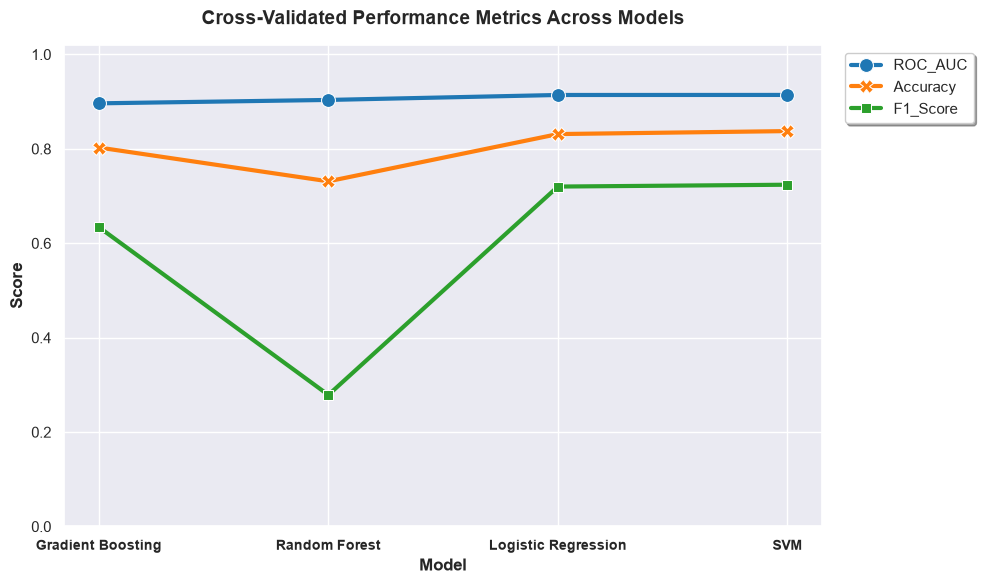

In [8]:
models_perf = cv_df.rename(columns={
    'CV ROC-AUC Mean': 'ROC_AUC', 'CV Accuracy': 'Accuracy', 'CV F1-Score': 'F1_Score'
})[['Model', 'ROC_AUC', 'Accuracy', 'F1_Score']]

df_melted = models_perf.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.set_theme(style="darkgrid")

sns.lineplot(data=df_melted, x='Model', y='Score', hue='Metric', style='Metric',
             markers=True, dashes=False, linewidth=3, palette='tab10', markersize=10)

plt.title('Cross-Validated Performance Metrics Across Models', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xticks(fontsize=10, fontweight='bold')
plt.ylim(0.0, 1.02)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='white', shadow=True)
plt.tight_layout()
plt.show()


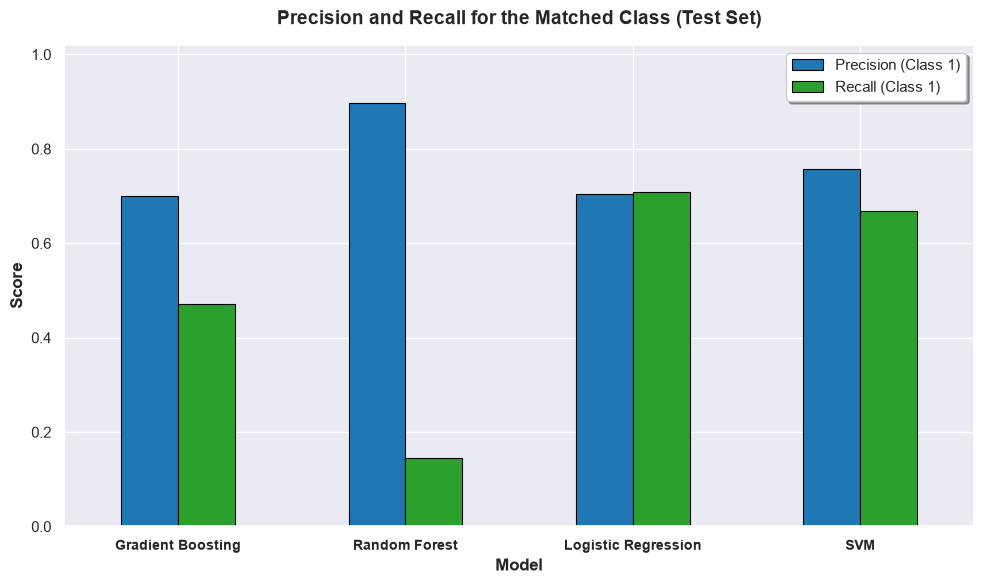

In [9]:
metrics_summary = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    metrics_summary.append({
        'Model': name,
        'Precision (Class 1)': precision_score(y_test, y_pred),
        'Recall (Class 1)': recall_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(metrics_summary)

ax = metrics_df.set_index('Model').plot(
    kind='bar', figsize=(10, 6), color=['#1f77b4', '#2ca02c'],
    edgecolor='black', linewidth=0.8
)

plt.title('Precision and Recall for the Matched Class (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=10, fontweight='bold')
plt.ylim(0.0, 1.02)
plt.legend(frameon=True, facecolor='white', shadow=True, fontsize=11)
plt.tight_layout()
plt.show()


## 8. Final Model Selection

The best-performing model is selected programmatically as the classifier with the highest mean cross-validated ROC-AUC, rather than being fixed in advance. This ensures the selection remains valid if the dataset or feature set is later modified.

In [10]:
best_model_name = cv_df.set_index('Model')['CV ROC-AUC Mean'].idxmax()
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)

print(f"Selected model: {best_model_name}")
print(cv_df.set_index('Model').loc[best_model_name])


c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Selected model: SVM
CV ROC-AUC Mean    0.9142
CV ROC-AUC Std     0.0109
CV Accuracy        0.8376
CV F1-Score        0.7240
Name: SVM, dtype: float64


## 9. Confusion Matrix

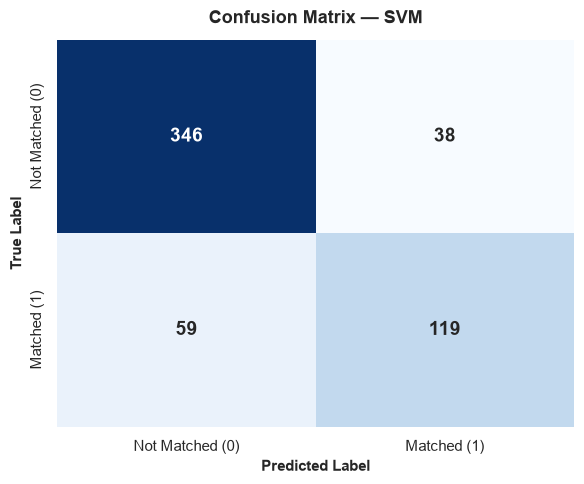

In [11]:
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
  annot_kws={"size": 14, "weight": "bold"},
  xticklabels=['Not Matched (0)', 'Matched (1)'],
  yticklabels=['Not Matched (0)', 'Matched (1)'])

plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', fontsize=11, fontweight='bold')
plt.ylabel('True Label', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Learning Curve

The learning curve is used to diagnose bias and variance behavior: convergence between training and cross-validation accuracy as training set size increases indicates a well-generalizing model, whereas a persistent gap would suggest overfitting.

c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Zeinab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\

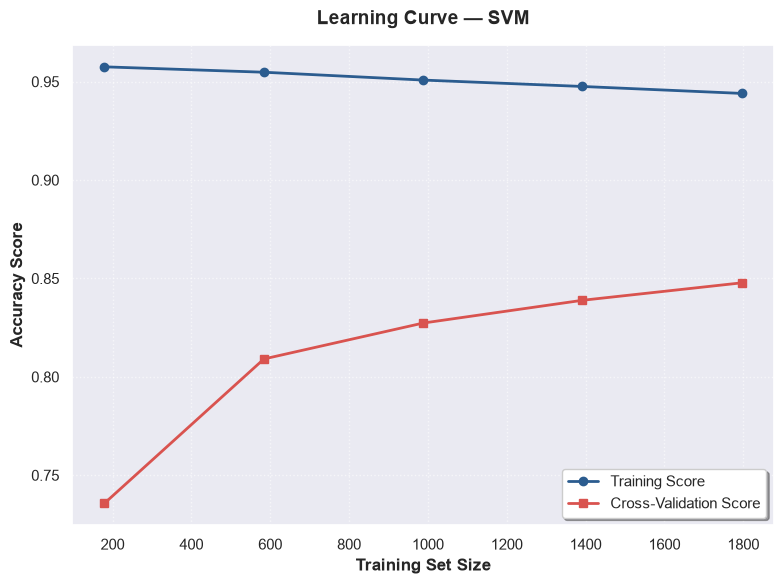

In [12]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o', color='#2b5c8f', lw=2)
plt.plot(train_sizes, val_mean, label='Cross-Validation Score', marker='s', color='#d9534f', lw=2)

plt.title(f'Learning Curve — {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Training Set Size', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', frameon=True, facecolor='white', shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


## 11. Precision-Recall Curve

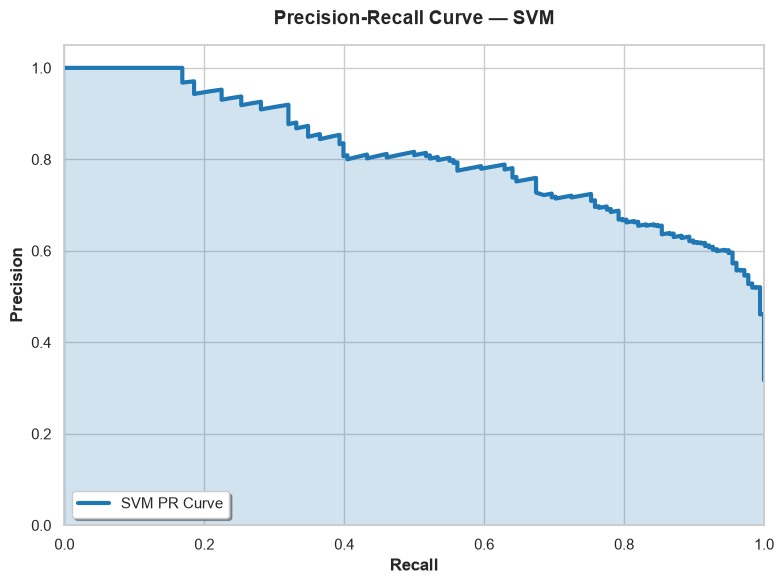

In [13]:
y_scores = best_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

plt.plot(recall, precision, color='#1f77b4', linewidth=3, label=f'{best_model_name} PR Curve')
plt.fill_between(recall, precision, alpha=0.2, color='#1f77b4')

plt.title(f'Precision-Recall Curve — {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower left', frameon=True, facecolor='white', shadow=True)
plt.tight_layout()
plt.show()


## 12. Feature Importance (Permutation Importance)

Because the selected model may not be tree-based (and therefore may not expose native `feature_importances_`), permutation importance is used instead. This method is model-agnostic: it measures the decrease in ROC-AUC when a single feature's values are randomly shuffled, holding all others fixed.

In [14]:
perm_result = permutation_importance(
    best_model, X_test_scaled, y_test, n_repeats=10, random_state=42, scoring='roc_auc'
)
importances = pd.Series(
    perm_result.importances_mean, index=X_test_scaled.columns
).sort_values(ascending=False)

print(f"=== Permutation Importance — {best_model_name} ===")
print(importances.head(10))


=== Permutation Importance — SVM ===
Internship_Experience    0.129636
Min_Experience_Months    0.114579
Skill_1                  0.026027
Required_Skill_3         0.023846
Skill_2                  0.023591
Required_Skill_5         0.022893
Required_Skill_1         0.022255
Skill_5                  0.017274
Skill_3                  0.015606
Required_Skill_2         0.012001
dtype: float64


## 13. Model Persistence

The final trained model, the fitted scaler, and the ordered feature column list are serialized for downstream deployment.

### Deployment Note — One-Hot Encoded Inputs
The model is trained on features produced by One-Hot Encoding, and expects a fixed, ordered column layout, saved in `feature_columns.pkl`. Any new input received from the application front end must be:

1. Transformed using the same One-Hot Encoding scheme (applied to `Gender`, `Vocational_Program`, `Job_Title`, `Location`);
2. Reindexed to match the exact column order stored in `feature_columns.pkl`, with missing columns filled with 0 (e.g., for a category not present in that particular request);
3. Passed through `scaler.transform(...)` prior to being fed into the model.

The skill-gap diagnostic breakdown presented in the application interface is computed directly from raw values (a transparent arithmetic calculation) and is independent of this predictive model; it requires no changes.

In [15]:
joblib.dump(best_model, "best_job_match_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print(f"Saved best model: {best_model_name}")
print("Files: best_job_match_model.pkl, scaler.pkl, feature_columns.pkl")


Saved best model: SVM
Files: best_job_match_model.pkl, scaler.pkl, feature_columns.pkl
